# 📊 DVF Data Exploration — Step 1
## Real Estate Analysis in Paris

**Author:** Ahmed Maala  
**Team:** Ahmed Maala & Natalja Voth  
**Date:** May 9, 2026  
**Project:** Liora Data Engineering Training

---

## 🎯 Objectives
1. Download DVF dataset from data.gouv.fr
2. Explore the data structure
3. Identify missing values
4. Filter data for Paris only
5. Save cleaned dataset

In [1]:
# ===== Standard Libraries =====
import os
import sys
from pathlib import Path

# ===== Data Manipulation =====
import pandas as pd
import numpy as np

# ===== Visualization =====
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Web Requests =====
import requests

# ===== Display Settings =====
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# ===== Confirmation =====
print("✅ All libraries imported successfully!")
print(f"📦 pandas version: {pd.__version__}")
print(f"📦 numpy version: {np.__version__}")

✅ All libraries imported successfully!
📦 pandas version: 3.0.2
📦 numpy version: 2.4.4


## 📥 Step 1: Download DVF Dataset

We download the 2022 DVF dataset from the official French government 
open data portal (data.gouv.fr).

**Source:** https://www.data.gouv.fr/fr/datasets/demandes-de-valeurs-foncieres-geolocalisees/

**File:** Compressed CSV (~150 MB)

In [2]:
# ===== Configuration with ABSOLUTE PATH =====
DATA_URL = "https://files.data.gouv.fr/geo-dvf/latest/csv/2022/full.csv.gz"

# Use absolute path - works from any location
PROJECT_ROOT = Path(r"C:\Users\ahmed\Documents\Projects\real-estate-paris")
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FILENAME = "dvf_2022.csv.gz"
FILEPATH = DATA_DIR / FILENAME

print(f"📍 Target location: {FILEPATH}")
print(f"📁 Directory exists: {DATA_DIR.exists()}\n")

# Create directory if not exists
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Check if file already exists
if FILEPATH.exists():
    file_size_mb = FILEPATH.stat().st_size / (1024 * 1024)
    print(f"✅ File already exists at: {FILEPATH}")
    print(f"📦 Size: {file_size_mb:.2f} MB")
else:
    print(f"⬇️  Downloading from: {DATA_URL}")
    print(f"📁 Saving to: {FILEPATH}")
    print(f"⏰ This may take 5-15 minutes...\n")
    
    response = requests.get(DATA_URL, stream=True)
    response.raise_for_status()
    
    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0
    last_printed_mb = 0
    
    with open(FILEPATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            downloaded += len(chunk)
            mb_downloaded = downloaded / (1024 * 1024)
            if mb_downloaded - last_printed_mb >= 10:
                if total_size > 0:
                    percent = (downloaded / total_size) * 100
                    print(f"  📊 Downloaded: {mb_downloaded:.1f} MB ({percent:.1f}%)")
                else:
                    print(f"  📊 Downloaded: {mb_downloaded:.1f} MB")
                last_printed_mb = mb_downloaded
    
    file_size_mb = FILEPATH.stat().st_size / (1024 * 1024)
    print(f"\n✅ Download complete!")
    print(f"📦 File size: {file_size_mb:.2f} MB")

📍 Target location: C:\Users\ahmed\Documents\Projects\real-estate-paris\data\raw\dvf_2022.csv.gz
📁 Directory exists: True

✅ File already exists at: C:\Users\ahmed\Documents\Projects\real-estate-paris\data\raw\dvf_2022.csv.gz
📦 Size: 117.07 MB


## 📖 Step 2: Load DVF Dataset into pandas

We load the compressed CSV file directly without extracting it.
pandas can read compressed files automatically.

**Note:** This may take 1-2 minutes due to the file size.

In [3]:
print("📖 Reading DVF dataset...")
print("⏰ Please wait, this may take 1-2 minutes...\n")

# Read the compressed CSV file
df_dvf = pd.read_csv(
    FILEPATH,
    compression='gzip',
    low_memory=False
)

# Confirmation
print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df_dvf.shape}")
print(f"   • Rows: {df_dvf.shape[0]:,}")
print(f"   • Columns: {df_dvf.shape[1]}")
print(f"💾 Memory usage: {df_dvf.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

📖 Reading DVF dataset...
⏰ Please wait, this may take 1-2 minutes...

✅ Dataset loaded successfully!
📊 Shape: (4676187, 40)
   • Rows: 4,676,187
   • Columns: 40
💾 Memory usage: 5012.50 MB


## 🔍 Step 3: Explore Data Structure

In [4]:
# Display first 5 rows
print("🔍 First 5 rows of the dataset:")
df_dvf.head()

🔍 First 5 rows of the dataset:


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2022-1,2022-01-03,1,Vente,55000.0,13.0,NaN,RUE DE LA LIBERTE,2280,1000.0,01053,Bourg-en-Bresse,01,NaN,NaN,01053000AM0102,NaN,NaN,7,24.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,24.0,1.0,NaN,NaN,NaN,NaN,NaN,5.218712,46.198053
1,2022-2,2022-01-03,1,Vente,143000.0,NaN,NaN,CHAMP COCHET,B010,1480.0,01398,Savigneux,01,NaN,NaN,01398000ZE0184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,S,sols,NaN,NaN,84.0,4.847876,46.000616
2,2022-2,2022-01-03,1,Vente,143000.0,NaN,NaN,CHAMP COCHET,B010,1480.0,01398,Savigneux,01,NaN,NaN,01398000ZE0185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,S,sols,NaN,NaN,88.0,4.847927,46.000598
3,2022-2,2022-01-03,1,Vente,143000.0,98.0,NaN,RTE DE LA DOMBES,0055,1480.0,01398,Savigneux,01,NaN,NaN,01398000ZE0187,NaN,NaN,1,123.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0,Appartement,140.0,3.0,NaN,NaN,NaN,NaN,NaN,4.848340,46.000631
4,2022-3,2022-01-04,1,Vente,300.0,NaN,NaN,AUX PIERRES,B031,1480.0,01243,Messimy-sur-Saône,01,NaN,NaN,012430000A0643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,T,terres,NaN,NaN,510.0,4.747594,46.045423


In [5]:
# List all columns
print(f"📋 Total columns: {len(df_dvf.columns)}\n")
print("Column names:")
for i, col in enumerate(df_dvf.columns, 1):
    print(f"  {i:2d}. {col}")

📋 Total columns: 40

Column names:
   1. id_mutation
   2. date_mutation
   3. numero_disposition
   4. nature_mutation
   5. valeur_fonciere
   6. adresse_numero
   7. adresse_suffixe
   8. adresse_nom_voie
   9. adresse_code_voie
  10. code_postal
  11. code_commune
  12. nom_commune
  13. code_departement
  14. ancien_code_commune
  15. ancien_nom_commune
  16. id_parcelle
  17. ancien_id_parcelle
  18. numero_volume
  19. lot1_numero
  20. lot1_surface_carrez
  21. lot2_numero
  22. lot2_surface_carrez
  23. lot3_numero
  24. lot3_surface_carrez
  25. lot4_numero
  26. lot4_surface_carrez
  27. lot5_numero
  28. lot5_surface_carrez
  29. nombre_lots
  30. code_type_local
  31. type_local
  32. surface_reelle_bati
  33. nombre_pieces_principales
  34. code_nature_culture
  35. nature_culture
  36. code_nature_culture_speciale
  37. nature_culture_speciale
  38. surface_terrain
  39. longitude
  40. latitude


In [6]:
# Column information
print("📋 Column information:\n")
df_dvf.info()

📋 Column information:

<class 'pandas.DataFrame'>
RangeIndex: 4676187 entries, 0 to 4676186
Data columns (total 40 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   id_mutation                   str    
 1   date_mutation                 str    
 2   numero_disposition            int64  
 3   nature_mutation               str    
 4   valeur_fonciere               float64
 5   adresse_numero                float64
 6   adresse_suffixe               str    
 7   adresse_nom_voie              str    
 8   adresse_code_voie             str    
 9   code_postal                   float64
 10  code_commune                  str    
 11  nom_commune                   str    
 12  code_departement              str    
 13  ancien_code_commune           float64
 14  ancien_nom_commune            str    
 15  id_parcelle                   str    
 16  ancien_id_parcelle            str    
 17  numero_volume                 str    
 18  lot1_numer

In [7]:
# Statistical summary
print("📊 Statistical summary:")
df_dvf.describe()

📊 Statistical summary:


,numero_disposition,valeur_fonciere,adresse_numero,code_postal,ancien_code_commune,lot1_surface_carrez,lot2_surface_carrez,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,surface_reelle_bati,nombre_pieces_principales,surface_terrain,longitude,latitude
count,4.676187e+06,4.644327e+06,3.000197e+06,4.639091e+06,40.000000,424210.000000,142695.000000,16146.000000,27023.000000,3968.000000,11657.000000,1476.000000,4.676187e+06,2.844898e+06,1.582571e+06,2.842070e+06,3.128378e+06,4.558151e+06,4.558151e+06
mean,1.377410e+00,2.801826e+06,7.042786e+02,5.005176e+04,15533.900000,70.985004,64.044527,72.840716,99.825112,86.553208,117.906065,90.716233,4.577107e-01,2.278719e+00,1.151442e+02,1.741532e+00,2.796739e+03,2.309373e+00,4.611599e+01
std,1.509881e+01,2.675176e+07,1.999961e+03,2.735210e+04,5489.081563,276.585776,72.384451,75.922752,2003.206082,136.119208,3002.542513,94.008073,8.668303e-01,9.176948e-01,7.419853e+02,2.061193e+00,1.562303e+04,6.326351e+00,5.791940e+00
min,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+03,14666.000000,0.080000,0.330000,0.690000,2.000000,1.010000,2.000000,0.800000,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,-6.314872e+01,-2.138654e+01
25%,1.000000e+00,7.600000e+04,8.000000e+00,2.826000e+04,14666.000000,36.390000,44.000000,42.040000,7.000000,40.967500,7.000000,36.070000,0.000000e+00,1.000000e+00,4.900000e+01,0.000000e+00,2.450000e+02,2.975010e-01,4.465422e+01
50%,1.000000e+00,1.750000e+05,2.500000e+01,4.926000e+04,14666.000000,55.880000,61.580000,62.570000,19.000000,67.940000,18.000000,71.265000,0.000000e+00,2.000000e+00,7.400000e+01,1.000000e+00,6.090000e+02,2.355245e+00,4.671583e+01
75%,1.000000e+00,3.201500e+05,9.800000e+01,7.500800e+04,14666.000000,74.680000,76.640000,86.770000,57.000000,101.290000,51.000000,120.945000,1.000000e+00,3.000000e+00,1.040000e+02,3.000000e+00,1.675000e+03,4.633449e+00,4.865285e+01
max,1.246000e+03,1.003401e+09,9.999000e+03,9.749000e+04,49382.000000,9532.000000,8705.000000,3888.000000,221311.000000,4765.300000,221312.000000,1538.000000,1.880000e+02,4.000000e+00,2.900000e+05,9.000000e+01,4.625500e+06,5.583003e+01,8.351771e+01


## ❓ Step 4: Missing Values Analysis

Missing values are a common problem in real-world datasets.
We need to identify them before any analysis.

According to the project requirements:
- Delete columns with more than 50% missing values
- Delete rows with any missing values (after column cleaning)

In [8]:
# Count missing values per column
missing_counts = df_dvf.isnull().sum()
missing_percent = (df_dvf.isnull().sum() / len(df_dvf)) * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percent': missing_percent.values
})

# Sort by percentage descending
missing_summary = missing_summary.sort_values(
    'Missing_Percent', 
    ascending=False
)

# Display
print("❓ Missing Values Summary (sorted by % missing):\n")
missing_summary

❓ Missing Values Summary (sorted by % missing):



,Column,Missing_Count,Missing_Percent
16,ancien_id_parcelle,4676185,99.999957
14,ancien_nom_commune,4676147,99.999145
13,ancien_code_commune,4676147,99.999145
27,lot5_surface_carrez,4674711,99.968436
25,lot4_surface_carrez,4672219,99.915145
17,numero_volume,4665706,99.775864
26,lot5_numero,4664530,99.750716
23,lot3_surface_carrez,4660041,99.654719
24,lot4_numero,4649164,99.422115
22,lot3_numero,4592467,98.209652


In [9]:
# Quick summary
total_cells = df_dvf.size
missing_cells = df_dvf.isnull().sum().sum()

print(f"📊 Total cells: {total_cells:,}")
print(f"❓ Missing cells: {missing_cells:,}")
print(f"📉 Missing percentage: {(missing_cells/total_cells)*100:.2f}%")
print(f"\n🔍 Columns with missing values:")
print(f"   • >50% missing: {len(missing_summary[missing_summary['Missing_Percent'] > 50])}")
print(f"   • 25-50% missing: {len(missing_summary[(missing_summary['Missing_Percent'] >= 25) & (missing_summary['Missing_Percent'] <= 50)])}")
print(f"   • <25% missing: {len(missing_summary[(missing_summary['Missing_Percent'] > 0) & (missing_summary['Missing_Percent'] < 25)])}")
print(f"   • 0% missing (complete): {len(missing_summary[missing_summary['Missing_Percent'] == 0])}")

📊 Total cells: 187,047,480
❓ Missing cells: 91,476,930
📉 Missing percentage: 48.91%

🔍 Columns with missing values:
   • >50% missing: 18
   • 25-50% missing: 7
   • <25% missing: 6
   • 0% missing (complete): 9


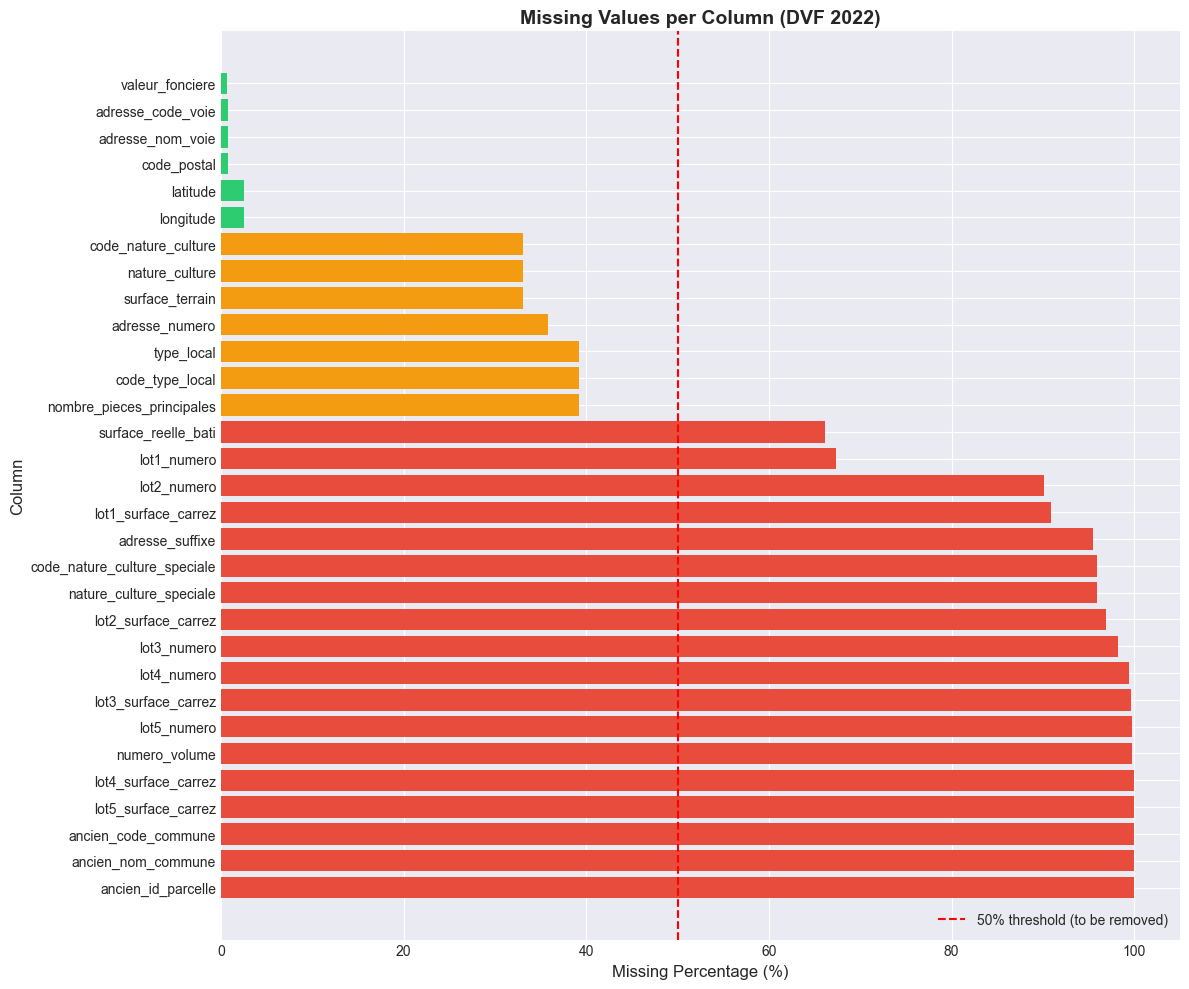


📊 Color legend:
  🔴 Red:    >50% missing (will be removed)
  🟠 Orange: 25-50% missing
  🟢 Green:  <25% missing


In [10]:
# Filter columns with missing values
cols_with_missing = missing_summary[missing_summary['Missing_Percent'] > 0]

# Plot
plt.figure(figsize=(12, 10))
bars = plt.barh(
    cols_with_missing['Column'], 
    cols_with_missing['Missing_Percent'],
    color=['#e74c3c' if p > 50 else '#f39c12' if p > 25 else '#2ecc71' 
           for p in cols_with_missing['Missing_Percent']]
)
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.title('Missing Values per Column (DVF 2022)', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold (to be removed)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\n📊 Color legend:")
print(f"  🔴 Red:    >50% missing (will be removed)")
print(f"  🟠 Orange: 25-50% missing")
print(f"  🟢 Green:  <25% missing")

## 🧹 Step 5: Data Cleaning

According to project requirements, we will:
1. **Filter Paris only** (department 75)
2. **Delete columns** with more than 50% missing values
3. **Delete rows** with any remaining missing values

In [11]:
# ===== Step 5.1: Filter Paris (department 75) =====
print("🇫🇷 Step 5.1: Filtering Paris data only (department 75)\n")

print(f"📊 Before filtering:")
print(f"   • Total rows: {len(df_dvf):,}")
print(f"   • Unique departments: {df_dvf['code_departement'].nunique()}")

# Filter Paris
df_paris = df_dvf[df_dvf['code_departement'] == '75'].copy()

print(f"\n✅ After filtering (Paris only):")
print(f"   • Total rows: {len(df_paris):,}")
print(f"   • Unique departments: {df_paris['code_departement'].nunique()}")
print(f"   • Reduction: {(1 - len(df_paris)/len(df_dvf)) * 100:.2f}%")

print(f"\n🔍 Verification:")
print(f"   • Department codes in filtered data: {df_paris['code_departement'].unique()}")
print(f"\n💾 Memory usage: {df_paris.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

🇫🇷 Step 5.1: Filtering Paris data only (department 75)

📊 Before filtering:
   • Total rows: 4,676,187
   • Unique departments: 97

✅ After filtering (Paris only):
   • Total rows: 98,308
   • Unique departments: 1
   • Reduction: 97.90%

🔍 Verification:
   • Department codes in filtered data: <StringArray>
['75']
Length: 1, dtype: str

💾 Memory usage: 106.65 MB


In [12]:
# ===== Step 5.2: Delete columns with >50% missing values =====
print("🗑️ Step 5.2: Removing columns with >50% missing values\n")

# Calculate missing % for Paris data
missing_paris = (df_paris.isnull().sum() / len(df_paris)) * 100

# Identify columns to drop
cols_to_drop = missing_paris[missing_paris > 50].index.tolist()

print(f"📋 Columns to be removed ({len(cols_to_drop)}):")
for i, col in enumerate(cols_to_drop, 1):
    print(f"   {i:2d}. {col} ({missing_paris[col]:.2f}% missing)")

# Drop them
df_paris_cleaned = df_paris.drop(columns=cols_to_drop)

print(f"\n✅ Result:")
print(f"   • Before: {len(df_paris.columns)} columns")
print(f"   • After: {len(df_paris_cleaned.columns)} columns")
print(f"   • Removed: {len(cols_to_drop)} columns")

print(f"\n📋 Remaining columns ({len(df_paris_cleaned.columns)}):")
for i, col in enumerate(df_paris_cleaned.columns, 1):
    pct = (df_paris_cleaned[col].isnull().sum() / len(df_paris_cleaned)) * 100
    status = "✅" if pct == 0 else "⚠️" if pct < 25 else "🟠"
    print(f"   {status} {i:2d}. {col} ({pct:.2f}% missing)")

🗑️ Step 5.2: Removing columns with >50% missing values

📋 Columns to be removed (19):
    1. adresse_suffixe (95.78% missing)
    2. ancien_code_commune (100.00% missing)
    3. ancien_nom_commune (100.00% missing)
    4. ancien_id_parcelle (100.00% missing)
    5. numero_volume (99.43% missing)
    6. lot1_surface_carrez (59.54% missing)
    7. lot2_numero (55.36% missing)
    8. lot2_surface_carrez (87.45% missing)
    9. lot3_numero (92.16% missing)
   10. lot3_surface_carrez (98.64% missing)
   11. lot4_numero (97.09% missing)
   12. lot4_surface_carrez (99.60% missing)
   13. lot5_numero (98.84% missing)
   14. lot5_surface_carrez (99.89% missing)
   15. code_nature_culture (91.52% missing)
   16. nature_culture (91.52% missing)
   17. code_nature_culture_speciale (99.85% missing)
   18. nature_culture_speciale (99.85% missing)
   19. surface_terrain (91.52% missing)

✅ Result:
   • Before: 40 columns
   • After: 21 columns
   • Removed: 19 columns

📋 Remaining columns (21):
   ✅ 

In [13]:
# ===== Step 5.3: Delete rows with any missing values =====
print("🗑️ Step 5.3: Removing rows with any missing values\n")

print(f"📊 Before dropping rows:")
print(f"   • Total rows: {len(df_paris_cleaned):,}")
print(f"   • Total missing cells: {df_paris_cleaned.isnull().sum().sum():,}")

# Drop rows with any NaN
df_paris_final = df_paris_cleaned.dropna()

print(f"\n✅ After dropping rows:")
print(f"   • Total rows: {len(df_paris_final):,}")
print(f"   • Total missing cells: {df_paris_final.isnull().sum().sum():,}")
print(f"   • Reduction: {(1 - len(df_paris_final)/len(df_paris_cleaned)) * 100:.2f}%")

print(f"\n🎯 Final Clean Dataset:")
print(f"   • Rows: {len(df_paris_final):,}")
print(f"   • Columns: {len(df_paris_final.columns)}")
print(f"   • Missing values: {df_paris_final.isnull().sum().sum():,}")
print(f"   • Memory usage: {df_paris_final.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

🗑️ Step 5.3: Removing rows with any missing values

📊 Before dropping rows:
   • Total rows: 98,308
   • Total missing cells: 65,551

✅ After dropping rows:
   • Total rows: 45,207
   • Total missing cells: 0
   • Reduction: 54.01%

🎯 Final Clean Dataset:
   • Rows: 45,207
   • Columns: 21
   • Missing values: 0
   • Memory usage: 31.73 MB


## 💾 Step 6: Save Cleaned Data

We save the cleaned Paris dataset to `data/processed/` for use 
in the next steps of the project (Database Modeling, ETL).

In [14]:
# ===== Step 6: Save cleaned data =====
print("💾 Saving cleaned Paris dataset...\n")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_DIR / "dvf_paris_2022_cleaned.csv"

# Save as CSV
df_paris_final.to_csv(OUTPUT_FILE, index=False)

# Verify
file_size_mb = OUTPUT_FILE.stat().st_size / (1024 * 1024)
print(f"✅ File saved successfully!")
print(f"📍 Location: {OUTPUT_FILE}")
print(f"📦 File size: {file_size_mb:.2f} MB")
print(f"📊 Rows: {len(df_paris_final):,}")
print(f"📋 Columns: {len(df_paris_final.columns)}")

# Save compressed version
COMPRESSED_FILE = PROCESSED_DIR / "dvf_paris_2022_cleaned.csv.gz"
df_paris_final.to_csv(COMPRESSED_FILE, index=False, compression='gzip')

compressed_size_mb = COMPRESSED_FILE.stat().st_size / (1024 * 1024)
print(f"\n📦 Compressed version:")
print(f"   • Location: {COMPRESSED_FILE}")
print(f"   • Size: {compressed_size_mb:.2f} MB")
print(f"   • Compression ratio: {(1 - compressed_size_mb/file_size_mb)*100:.1f}%")

💾 Saving cleaned Paris dataset...

✅ File saved successfully!
📍 Location: C:\Users\ahmed\Documents\Projects\real-estate-paris\data\processed\dvf_paris_2022_cleaned.csv
📦 File size: 7.64 MB
📊 Rows: 45,207
📋 Columns: 21

📦 Compressed version:
   • Location: C:\Users\ahmed\Documents\Projects\real-estate-paris\data\processed\dvf_paris_2022_cleaned.csv.gz
   • Size: 1.43 MB
   • Compression ratio: 81.3%


## 📝 Summary

### 🎯 What We Accomplished

**Starting point:**
- 📦 Raw DVF 2022 dataset from data.gouv.fr
- 📊 4,676,187 rows × 40 columns
- 💾 5 GB in memory

**Cleaning steps applied:**
1. ✅ Filtered to Paris only (department 75)
2. ✅ Removed 19 columns with >50% missing values
3. ✅ Removed rows with any remaining missing values

**Final clean dataset:**
- 📊 45,207 rows × 21 columns
- 💾 31.73 MB in memory
- ✨ 0 missing values

### 📊 Key Findings

1. **Data Quality Issues:**
   - 48.91% of all cells had missing values
   - 19 columns (almost half) had >50% missing data
   - Some columns were 100% empty for Paris data

2. **Paris Real Estate Activity:**
   - 98,308 transactions in Paris in 2022 (before cleaning)
   - 45,207 valid transactions with complete data

### 🔍 Notable Observations

- `surface_reelle_bati` had 48.83% missing — just below the 50% threshold
- This single column caused ~54% row loss when removing incomplete rows
- **Recommendation:** Consider alternative imputation strategies for important columns

### 🚀 Next Steps

1. **Connect to opendata.paris API** for additional data:
   - Risk sectors
   - Rent control prices
   - Green spaces
2. **Design database schema** (3NF) for Step 2
3. **Build ETL pipeline** for Step 3
4. **Create Power BI dashboard** for Step 4